In [72]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [73]:
root_data_path = Path.cwd() / "Datos_Experimentales" / "Medidas Arturo"
data_path = root_data_path / "DC_Reset#1_1000nm-TopMIM.xlsx"

nombre_txt = "MIM_Reset_1_Run"
nombre_media_file = "Mean_MIM_Reset_1"
voltage_column_name = "SourceV" 
current_column_name = "SourceI"

In [74]:
# Lee todas las hojas
sheets = pd.read_excel(data_path, sheet_name=None)  # dict: nombre_hoja -> DataFrame

for run in range(1, 65):  # de 4 a 64 inclusive
    sheet_name = f"Run{run}"
    if sheet_name not in sheets:
        continue  # por si falta alguna hoja

    df = sheets[sheet_name]

    # Eliminar columna GateV si existe
    if "GateV" in df.columns:
        df = df.drop(columns=["GateV"])

    # Renombrar columnas
    df = df.rename(
        columns={
            "Time": "Time (s)",
            current_column_name: "Current (A)",
            voltage_column_name: "Voltage (V)",
        }
    )

    txt_path = root_data_path / f"{nombre_txt}{run}.txt"

    df.to_csv(txt_path, sep="\t", index=False)


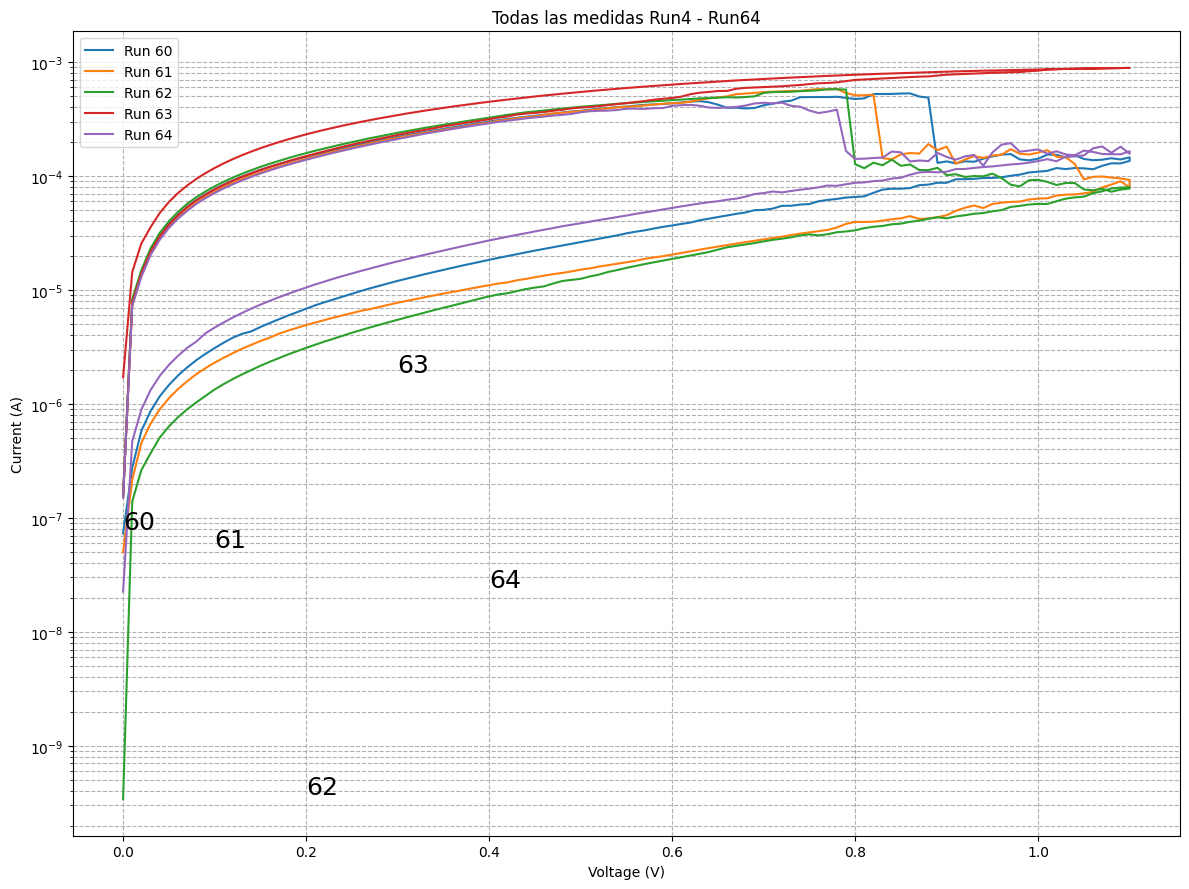

In [75]:
runs = range(60, 65)  # Run4 ... Run64

# Quito el run 21 y el 17 (que está mal)
# runs = [run for run in runs if run not in (17, 21,27)] # Para el set 1 D
# runs = [run for run in runs if run not in (17,4,27, 21, 64,5)] # Para el set 2 D
# runs = [run for run in runs if run not in (23,11,19,29,16)] # Para el reset 1 D
# runs = [run for run in runs if run not in (23,11,19,29,16)] # Para el set 1 MIM

data_frames = {}
for run in runs:
    txt_name = f"{nombre_txt}{run}.txt"
    txt_path = root_data_path / txt_name
    df = pd.read_csv(txt_path, sep="\t")  # lee tabulado
    df = df.rename(
        columns={
            "Time": "Time (s)",
            current_column_name: "Current (A)",
            voltage_column_name: "Voltage (V)",
        }
    )
    # print(f"Run {run}: ", df.columns.tolist())
    data_frames[run] = df

plt.figure(figsize=(12, 9))
i = 0
for run, df in data_frames.items():
    x = df["Voltage (V)"]
    y = df["Current (A)"]
    plt.semilogy(x, y, label=f"Run {run}")

    # Coordenadas del último punto
    x_last = x.iloc[-1]
    y_last = y.iloc[-1]

    # Texto ligeramente desplazado para que no se superponga con la curva
    plt.text(x_last+i, y_last, f"{run}", fontsize=18, ha="left", va="bottom")
    i = i + 0.1
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Todas las medidas Run4 - Run64")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()


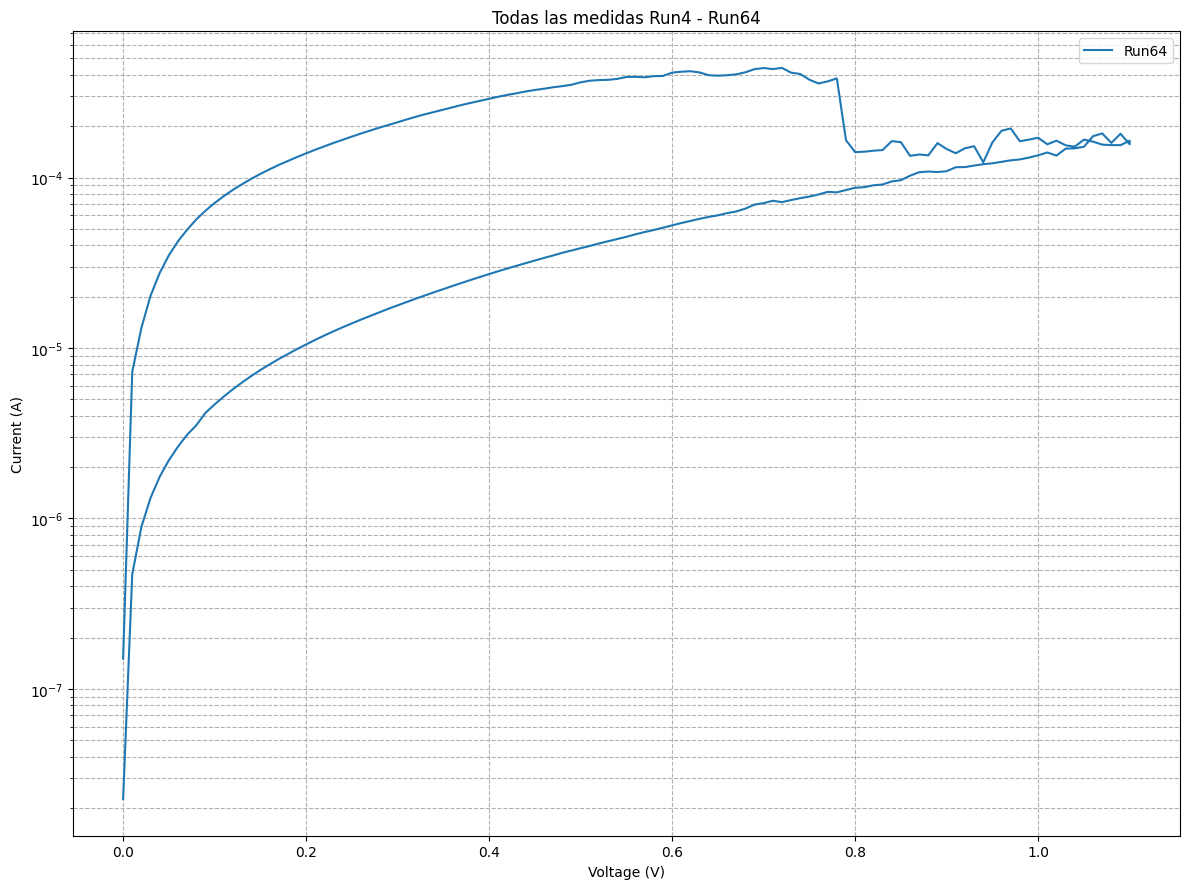

In [76]:
run = 64

txt_name = f"{nombre_txt}{run}.txt"
txt_path = root_data_path / txt_name
df = pd.read_csv(txt_path, sep="\t")  # lee tabulado
df = df.rename(
    columns={
        "Time": "Time (s)",
        current_column_name: "Current (A)",
        voltage_column_name: "Voltage (V)",
    }
)
# print(f"Run {run}: ", df.columns.tolist())
data_frames[run] = df

plt.figure(figsize=(12, 9))

x = df["Voltage (V)"]
y = df["Current (A)"]

plt.semilogy(x, y, label=f"Run{run}")

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Todas las medidas Run4 - Run64")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()


In [77]:
all_runs = range(10, 64)
# exclude = {17, 21, 27}
# exclude = {23, 11, 19, 29, 16}
# exclude = {17, 4, 27, 21, 64, 5} # Para el set 2
exclude = {89} # Para no cambiar el codigo pongo una curva q NO esta

dfs = []
for run in all_runs:
    if run in exclude:
        continue
    txt_name = f"{nombre_txt}{run}.txt"
    txt_path = root_data_path / txt_name
    df = pd.read_csv(txt_path, sep="\t")
    # Renombrar columnas
    df = df.rename(
        columns={
            "Time": "Time (s)",
            current_column_name: "Current (A)",
            voltage_column_name: "Voltage (V)",
        }
    )
    dfs.append(df)

df_concat = pd.concat(dfs, axis=0, keys=[r for r in all_runs if r not in exclude])
mean_df = df_concat.groupby(level=1).mean()

txt_path = root_data_path / nombre_media_file
    
mean_df.to_csv(f"{txt_path}.txt", sep="\t", index=False)


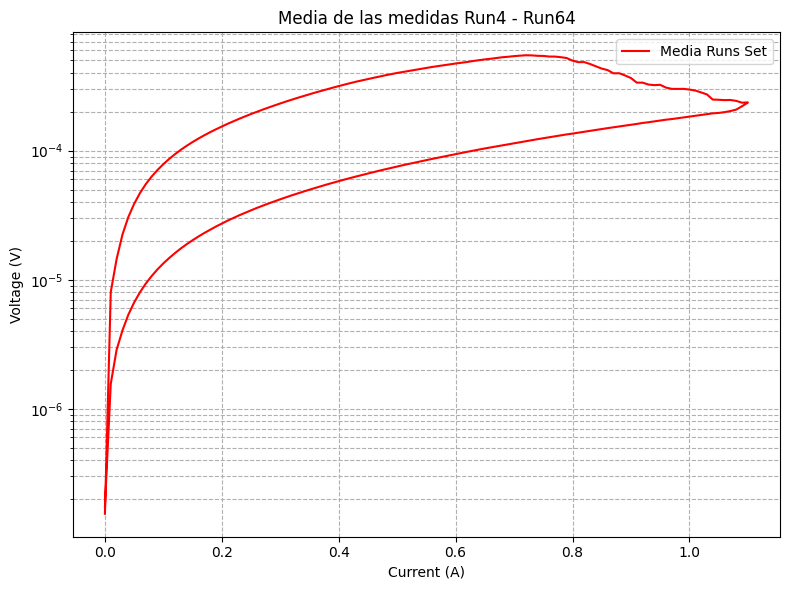

In [78]:
x_mean = mean_df["Voltage (V)"]
y_mean = mean_df["Current (A)"]

plt.figure(figsize=(8, 6))
plt.semilogy(x_mean, y_mean, label="Media Runs Set", color="red")
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Media de las medidas Run4 - Run64")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

